<a href="https://colab.research.google.com/github/Kari-2005/carisurg-portfolio/blob/main/notebooks/Week7/Week7_Interim_Model_Ansarah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Interim: Model Optimisation and Trade-Offs

**Student:** Ansarah Mohammed  
**Project:** Caribbean ED Validation of Machine-Learning Triage Support  
**Dataset:** Mercer Emergency Department Triage Dataset  
**Target variable:** ESI triage level  
**Random seed:** 42  

## Interim Objective

The purpose of this notebook is to investigate whether a more complex machine-learning model provides enough benefit to justify its additional computational and interpretability costs.

The original Week 6 logistic-regression and bounded decision-tree models are rebuilt and compared with a Random Forest classifier. All three models use the same ten triage-time predictor variables, the same 80/20 stratified train-test split, and the same random seed of 42. This ensures that differences in performance are caused by the modelling approach rather than changes to the patients or predictor variables used.

The models are compared using accuracy, precision, recall, F1-score, training time and inference time per patient. Interpretability is included as a seventh qualitative measure. Particular attention is given to recall for ESI Level 1 because missing a critically urgent patient may lead to dangerous under-triage.

In [88]:
# Data handling
import numpy as np
import pandas as pd

# Timing and file management
import time
import os

# Visualisation
import matplotlib.pyplot as plt

# Data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Week 6 baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Week 7 complex model
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Fixed settings used throughout the notebook
RANDOM_STATE = 42
TEST_SIZE = 0.20
ESI_LABELS = [1, 2, 3, 4, 5]

print("Libraries loaded successfully.")
print("Random seed:", RANDOM_STATE)
print("Test-set proportion:", TEST_SIZE)

Libraries loaded successfully.
Random seed: 42
Test-set proportion: 0.2


## Loading the Dataset

The Mercer Emergency Department triage dataset is loaded from Google Drive. The same dataset used for the Week 6 baseline modelling is reused so that the comparison remains consistent.

In [89]:
# Import the Google Drive connection provided by Colab
from google.colab import drive

# Connect the notebook to Google Drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
# Store the location of the dataset in one variable
# The same Week 5 dataset used during Week 6 is reused
DATA_PATH = "/content/drive/MyDrive/CARISURG/Week5/yaleemmlc_admissionprediction_triage.csv"

# Load the CSV file as a pandas DataFrame
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Number of patient records:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display the first five rows as an initial check
df.head()

Dataset loaded successfully.
Number of patient records: 55121
Number of columns: 226


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Select the Target and Predictor Variables

The target variable is `esi`, which represents the patient’s assigned Emergency Severity Index level.

The same ten predictor variables used for the original Week 6 baseline models are retained. These variables represent patient characteristics, vital signs and chief-complaint indicators available during triage. Post-triage information, including patient disposition, is excluded to reduce the risk of data leakage.

Using the same predictors ensures that the Week 7 Random Forest is compared fairly with the original logistic-regression and decision-tree models.

In [91]:
# Identify the outcome that the models will try to predict
TARGET = "esi"

# Reuse the exact ten predictor variables selected for Week 6
FEATURES = [
    "age",
    "triage_vital_o2_device",
    "triage_vital_o2",
    "cc_chestpain",
    "cc_shortnessofbreath",
    "cc_alteredmentalstatus",
    "triage_glucose",
    "triage_vital_hr",
    "triage_vital_rr",
    "triage_vital_sbp"
]

# Check that all selected predictors and the target exist in the dataset
required_columns = FEATURES + [TARGET]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

# Stop the notebook with a clear message if a required column is missing
if missing_columns:
    raise ValueError(
        f"The following required columns were not found: {missing_columns}"
    )

print("All required columns were found successfully.")
print("Number of predictor variables:", len(FEATURES))
print("Target variable:", TARGET)

print("\nSelected predictor variables:")
for number, feature in enumerate(FEATURES, start=1):
    print(f"{number}. {feature}")

All required columns were found successfully.
Number of predictor variables: 10
Target variable: esi

Selected predictor variables:
1. age
2. triage_vital_o2_device
3. triage_vital_o2
4. cc_chestpain
5. cc_shortnessofbreath
6. cc_alteredmentalstatus
7. triage_glucose
8. triage_vital_hr
9. triage_vital_rr
10. triage_vital_sbp


In [92]:
# Create a separate DataFrame containing only the selected predictors
# and the ESI target required for modelling
model_df = df[FEATURES + [TARGET]].copy()

print("Modelling dataset created successfully.")
print("Modelling dataset shape:", model_df.shape)

# Display the first five rows as a check
model_df.head()

Modelling dataset created successfully.
Modelling dataset shape: (55121, 11)


,age,triage_vital_o2_device,triage_vital_o2,cc_chestpain,cc_shortnessofbreath,cc_alteredmentalstatus,triage_glucose,triage_vital_hr,triage_vital_rr,triage_vital_sbp,esi
0,87.0,0.0,98.0,0.0,0.0,0.0,87.0,88.0,17.0,155.0,4.0
1,53.0,0.0,98.0,0.0,0.0,0.0,113.0,118.0,20.0,105.0,2.0
2,49.0,0.0,99.0,0.0,0.0,0.0,108.0,76.0,18.0,116.0,2.0
3,22.0,0.0,97.0,0.0,0.0,0.0,85.0,106.0,16.0,103.0,3.0
4,62.0,0.0,95.0,0.0,0.0,0.0,88.0,84.0,18.0,109.0,2.0


### Review the Target Distribution

The number and percentage of patients assigned to each ESI level are reviewed before modelling. This is important because the dataset is imbalanced, with considerably fewer ESI Level 1 and Level 5 patients than patients in the more common categories.

This imbalance means that accuracy alone may present an incomplete picture of model performance.

In [93]:
# Count the number of patients assigned to each ESI level
esi_counts = (
    model_df[TARGET]
    .value_counts()
    .sort_index()
)

# Calculate the percentage of patients in each ESI level
esi_percentages = (
    model_df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(3)
)

# Combine the counts and percentages into one table
esi_distribution = pd.DataFrame({
    "Patient Count": esi_counts,
    "Percentage (%)": esi_percentages
})

esi_distribution.index.name = "ESI Level"

print("Distribution of the ESI target:")
esi_distribution

Distribution of the ESI target:


,Patient Count,Percentage (%)
ESI Level,,
1.0,77,0.140
2.0,17924,32.518
3.0,27010,49.001
4.0,8896,16.139
5.0,1214,2.202


## Prepare the Data for Modelling

The selected predictors and target are checked for missing values before the data are divided into training and testing sets. Missing information could prevent some models from training correctly or introduce additional uncertainty into the comparison.

In [94]:
# Count missing values in each selected column
missing_values = model_df.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percentages = (
    missing_values / len(model_df) * 100
).round(3)

# Place the results into one table
missing_values_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage Missing (%)": missing_percentages
})

print("Missing values in the modelling dataset:")
missing_values_table

Missing values in the modelling dataset:


,Missing Values,Percentage Missing (%)
age,0,0.0
triage_vital_o2_device,0,0.0
triage_vital_o2,0,0.0
cc_chestpain,0,0.0
cc_shortnessofbreath,0,0.0
cc_alteredmentalstatus,0,0.0
triage_glucose,0,0.0
triage_vital_hr,0,0.0
triage_vital_rr,0,0.0
triage_vital_sbp,0,0.0


### Separate the Predictor and Target Variables

The ten predictor variables are stored as `X`, while the recorded ESI level is stored as `y`. The ESI values are converted to whole numbers because they represent categories rather than continuous measurements.

In [95]:
# Store the selected patient information in X
X = model_df[FEATURES].copy()

# Store the recorded ESI level in y
y = model_df[TARGET].copy()

# Convert ESI values to integers because they represent categories
y = y.astype(int)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

print("\nESI levels present in the target:")
print(sorted(y.unique()))

Predictor shape: (55121, 10)
Target shape: (55121,)

ESI levels present in the target:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Recreate the Week 6 Training and Testing Sets

The dataset is divided into an 80% training set and a 20% testing set. Stratification is used to keep the proportions of the five ESI levels similar in both groups.

The same random seed of 42 used in Week 6 is retained. This recreates the same training and testing patients and allows the Week 7 models to be compared honestly with the original baselines.

In [96]:
# Divide the data into the same 80% training and 20% testing groups
# used for the Week 6 baseline models
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train-test split created successfully.")

print("\nTraining predictor shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("\nTesting predictor shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Train-test split created successfully.

Training predictor shape: (44096, 10)
Training target shape: (44096,)

Testing predictor shape: (11025, 10)
Testing target shape: (11025,)


In [97]:
# Calculate the percentage of each ESI level in the training set
training_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(3)
)

# Calculate the percentage of each ESI level in the testing set
testing_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(3)
)

# Compare the class distributions
split_distribution = pd.DataFrame({
    "Training Set (%)": training_distribution,
    "Testing Set (%)": testing_distribution
})

split_distribution.index.name = "ESI Level"

print("ESI distribution after the stratified split:")
split_distribution

ESI distribution after the stratified split:


,Training Set (%),Testing Set (%)
ESI Level,,
1,0.138,0.145
2,32.518,32.517
3,49.002,48.998
4,16.140,16.136
5,2.202,2.204


## Evaluation Strategy and Metric Justification

The models are assessed using six quantitative measures: accuracy, precision, recall, F1-score, training time and inference time per patient. Interpretability is included as a seventh qualitative measure.

### Primary Clinical Metric: ESI Level 1 Recall

Recall for ESI Level 1 is treated as the primary clinical safety metric. It measures the proportion of genuinely critical patients that the model correctly identifies as requiring immediate care.

A false negative occurs when a true ESI Level 1 patient is assigned to a less urgent category. In an emergency department, this type of under-triage may delay immediate assessment, resuscitation or another life-saving intervention. For this reason, missing an ESI Level 1 patient is considered more clinically serious than incorrectly assigning a less urgent patient to a higher-priority category.

However, ESI Level 1 recall cannot be interpreted alone. A model could increase recall by predicting ESI Level 1 too frequently, which would create false alarms and unnecessary over-triage. ESI Level 1 precision is therefore also reviewed to determine how often Level 1 predictions are correct.

### Supporting Performance Measures

- **Accuracy** measures the overall proportion of correct predictions. It is reported for completeness but is not used alone because the dataset contains considerably more ESI Level 2 and Level 3 patients than ESI Level 1 patients.
- **Macro precision** calculates precision separately for each ESI level and gives all five classes equal importance.
- **Macro recall** calculates recall separately for each ESI level and gives all five classes equal importance.
- **Macro F1-score** balances precision and recall while giving equal importance to every ESI level. This makes weak performance among rare classes more visible.
- **Weighted F1-score** also balances precision and recall, but gives greater influence to classes containing more patients. It provides a useful measure of overall performance but may be dominated by the common ESI Levels 2 and 3.
- **The confusion matrix** shows the specific directions of the errors, including whether critically urgent patients were under-triaged.

### Computational and Interpretability Measures

- **Training time** measures how long the model takes to learn from the training data. This cost is normally paid only when the model is initially trained or updated.
- **Inference time per patient** measures how long the trained model takes to produce one prediction. This is particularly important for deployment because the cost is repeated for every patient assessed.
- **Interpretability** considers whether the reasoning behind a prediction can be explained to a clinician clearly and quickly.

No single measurement is expected to determine the final model choice. The recommendation will consider clinical performance, error patterns, computational cost and explainability together.

### Consistent Evaluation Function

A reusable function is created so that every model is assessed using the same calculations. This reduces repetition and helps prevent differences in the evaluation process from affecting the comparison.

In [98]:
# Create one function that calculates the required performance measures
# for each model using the same testing set
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    training_time,
    inference_time_ms,
    interpretability
):
    """
    Calculate the main clinical, performance and computational
    measures required for the Week 7 model comparison.
    """

    # Calculate overall accuracy
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    # Calculate macro-averaged scores
    # Each of the five ESI levels receives equal importance
    macro_precision = precision_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="macro",
        zero_division=0
    )

    # Calculate weighted F1
    # Larger ESI groups receive more influence
    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="weighted",
        zero_division=0
    )

    # Calculate precision and recall specifically for ESI Level 1
    # Level 1 is treated as the positive class for these calculations
    true_esi1 = (np.asarray(y_true) == 1)
    predicted_esi1 = (np.asarray(y_pred) == 1)

    esi1_precision = precision_score(
        true_esi1,
        predicted_esi1,
        zero_division=0
    )

    esi1_recall = recall_score(
        true_esi1,
        predicted_esi1,
        zero_division=0
    )

    # Return the results as one dictionary
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "ESI 1 Precision": esi1_precision,
        "ESI 1 Recall": esi1_recall,
        "Training Time (s)": training_time,
        "Inference Time (ms/patient)": inference_time_ms,
        "Interpretability": interpretability
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


## Rebuild the Original Logistic Regression Baseline

The original Week 6 Logistic Regression is rebuilt using the same ten predictor variables and the same training and testing patients.

The predictor variables use different units and numerical ranges. For example, age is measured in years, oxygen saturation is measured as a percentage, and heart rate is measured in beats per minute. Standardisation is therefore applied before training so that the variables are placed on a more comparable scale.

The scaler learns its values from the training data only. The same training-based transformation is then applied to the testing data, preventing information from the unseen patients from influencing model development.

The time required for scaling and training is included in the reported training time. Similarly, the time required to transform the testing data and generate predictions is included in the inference measurement.

In [99]:
# Start the timer before the training-data preparation begins
logistic_training_start = time.perf_counter()

# Create a scaler for the Logistic Regression predictors
logistic_scaler = StandardScaler()

# Learn the scaling values from the training data
# and apply the transformation to the training patients
X_train_scaled = logistic_scaler.fit_transform(X_train)

# Create the same Logistic Regression model used in Week 6
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train the model using the scaled training predictors
logistic_model.fit(
    X_train_scaled,
    y_train
)

# Stop the training timer
logistic_training_time = (
    time.perf_counter() - logistic_training_start
)

print("Logistic Regression trained successfully.")
print(
    "Training time:",
    round(logistic_training_time, 4),
    "seconds"
)

Logistic Regression trained successfully.
Training time: 1.0895 seconds


In [100]:
# Create an empty list to store repeated inference measurements
logistic_inference_runs = []

# Repeat the prediction process five times
# Repeated measurements reduce the effect of small timing fluctuations
for run in range(5):

    # Begin timing before the test features are transformed
    logistic_inference_start = time.perf_counter()

    # Apply the scaling values learned from the training data
    X_test_scaled = logistic_scaler.transform(X_test)

    # Generate predictions for all testing patients
    logistic_predictions = logistic_model.predict(
        X_test_scaled
    )

    # Stop the timer after all predictions have been produced
    total_inference_time = (
        time.perf_counter() - logistic_inference_start
    )

    # Divide the total time by the number of testing patients
    # and convert seconds to milliseconds
    inference_ms_per_patient = (
        total_inference_time / len(X_test)
    ) * 1000

    logistic_inference_runs.append(
        inference_ms_per_patient
    )

# Use the median of the five runs as the final inference measurement
logistic_inference_ms = float(
    np.median(logistic_inference_runs)
)

print("Logistic Regression predictions completed.")
print(
    "Median inference time:",
    round(logistic_inference_ms, 6),
    "milliseconds per patient"
)

print("\nFive inference measurements:")
for run_number, run_time in enumerate(
    logistic_inference_runs,
    start=1
):
    print(
        f"Run {run_number}:",
        round(run_time, 6),
        "ms per patient"
    )

Logistic Regression predictions completed.
Median inference time: 0.000722 milliseconds per patient

Five inference measurements:
Run 1: 0.000959 ms per patient
Run 2: 0.000722 ms per patient
Run 3: 0.000725 ms per patient
Run 4: 0.000251 ms per patient
Run 5: 0.000241 ms per patient


In [101]:
# Display precision, recall and F1-score separately
# for each of the five ESI levels
print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        labels=ESI_LABELS,
        target_names=[
            "ESI Level 1",
            "ESI Level 2",
            "ESI Level 3",
            "ESI Level 4",
            "ESI Level 5"
        ],
        digits=3,
        zero_division=0
    )
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

 ESI Level 1      0.000     0.000     0.000        16
 ESI Level 2      0.656     0.341     0.449      3585
 ESI Level 3      0.522     0.885     0.657      5402
 ESI Level 4      0.200     0.001     0.001      1779
 ESI Level 5      0.000     0.000     0.000       243

    accuracy                          0.545     11025
   macro avg      0.276     0.245     0.221     11025
weighted avg      0.502     0.545     0.468     11025



## Rebuild the Original Decision Tree Baseline

The original Week 6 Decision Tree is rebuilt using the same ten predictor variables and the same training and testing patients.

Unlike Logistic Regression, a Decision Tree does not require the numerical predictors to be standardised. It separates patients using a sequence of threshold-based decision rules, so the original feature values are retained.

The maximum tree depth is limited to five levels, matching the Week 6 baseline. This restriction helps reduce overfitting and keeps the model more understandable than an unrestricted tree.

Training time and inference time per patient are measured so that the computational cost of the Decision Tree can later be compared with the Logistic Regression and Random Forest models.

In [102]:
# Start the training timer
decision_tree_training_start = time.perf_counter()

# Create the same depth-limited Decision Tree used in Week 6
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE
)

# Train the model using the original, unscaled predictor values
decision_tree_model.fit(
    X_train,
    y_train
)

# Stop the training timer
decision_tree_training_time = (
    time.perf_counter() - decision_tree_training_start
)

print("Decision Tree trained successfully.")
print(
    "Training time:",
    round(decision_tree_training_time, 4),
    "seconds"
)

Decision Tree trained successfully.
Training time: 0.1004 seconds


In [103]:
# Create an empty list to store repeated inference measurements
decision_tree_inference_runs = []

# Repeat the prediction process five times
for run in range(5):

    # Begin timing immediately before prediction
    decision_tree_inference_start = time.perf_counter()

    # Generate predictions for all patients in the test set
    decision_tree_predictions = decision_tree_model.predict(
        X_test
    )

    # Stop the timer after prediction
    total_inference_time = (
        time.perf_counter() - decision_tree_inference_start
    )

    # Calculate inference time for one patient
    # and convert seconds to milliseconds
    inference_ms_per_patient = (
        total_inference_time / len(X_test)
    ) * 1000

    decision_tree_inference_runs.append(
        inference_ms_per_patient
    )

# Use the median result to reduce the effect of timing fluctuations
decision_tree_inference_ms = float(
    np.median(decision_tree_inference_runs)
)

print("Decision Tree predictions completed.")
print(
    "Median inference time:",
    round(decision_tree_inference_ms, 6),
    "milliseconds per patient"
)

print("\nFive inference measurements:")
for run_number, run_time in enumerate(
    decision_tree_inference_runs,
    start=1
):
    print(
        f"Run {run_number}:",
        round(run_time, 6),
        "ms per patient"
    )

Decision Tree predictions completed.
Median inference time: 0.00015 milliseconds per patient

Five inference measurements:
Run 1: 0.000295 ms per patient
Run 2: 0.0002 ms per patient
Run 3: 0.00015 ms per patient
Run 4: 0.000142 ms per patient
Run 5: 0.000149 ms per patient


In [104]:
# Evaluate the Decision Tree using the same function
# used for the Logistic Regression
decision_tree_results = evaluate_model(
    model_name="Decision Tree",
    y_true=y_test,
    y_pred=decision_tree_predictions,
    training_time=decision_tree_training_time,
    inference_time_ms=decision_tree_inference_ms,
    interpretability="High"
)

# Convert the results into a one-row DataFrame
decision_tree_results_table = pd.DataFrame(
    [decision_tree_results]
)

# Create a separate display version
decision_tree_results_display = (
    decision_tree_results_table.copy()
)

# Identify the numerical columns
numeric_columns = decision_tree_results_display.select_dtypes(
    include=np.number
).columns

# Round only the display copy
decision_tree_results_display[numeric_columns] = (
    decision_tree_results_display[numeric_columns].round(4)
)

print("Decision Tree benchmark results:")
decision_tree_results_display

Decision Tree benchmark results:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,Training Time (s),Inference Time (ms/patient),Interpretability
0,Decision Tree,0.5434,0.2404,0.2417,0.2152,0.4591,0.0,0.0,0.1004,0.0001,High


In [105]:
# Display the per-class Decision Tree results
print("Decision Tree Classification Report:")
print(
    classification_report(
        y_test,
        decision_tree_predictions,
        labels=ESI_LABELS,
        target_names=[
            "ESI Level 1",
            "ESI Level 2",
            "ESI Level 3",
            "ESI Level 4",
            "ESI Level 5"
        ],
        digits=3,
        zero_division=0
    )
)

Decision Tree Classification Report:
              precision    recall  f1-score   support

 ESI Level 1      0.000     0.000     0.000        16
 ESI Level 2      0.681     0.296     0.413      3585
 ESI Level 3      0.521     0.913     0.663      5402
 ESI Level 4      0.000     0.000     0.000      1779
 ESI Level 5      0.000     0.000     0.000       243

    accuracy                          0.543     11025
   macro avg      0.240     0.242     0.215     11025
weighted avg      0.477     0.543     0.459     11025



### Baseline Reproduction Check

The original Week 6 Logistic Regression and Decision Tree have now been rebuilt using the same ten predictors, stratified train-test split and random seed.

The results should remain very close to the Week 6 findings:

- Logistic Regression accuracy of approximately 0.545;
- Decision Tree accuracy of approximately 0.543;
- ESI Level 1 recall of 0.000 for both models.

Small differences in training and inference time are expected because timing depends on the available Colab hardware and current runtime conditions. The predictive performance metrics should remain unchanged or nearly unchanged.

Reproducing the original results before introducing the complex model provides evidence that the Week 7 comparison begins from a consistent baseline.

In [106]:
# Recreate the evaluation function in case the Colab runtime was restarted
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    training_time,
    inference_time_ms,
    interpretability
):
    """
    Calculate the performance and computational measures
    required for the Week 7 model comparison.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=ESI_LABELS,
        average="weighted",
        zero_division=0
    )

    # Convert ESI Level 1 into a binary comparison
    true_esi1 = np.asarray(y_true) == 1
    predicted_esi1 = np.asarray(y_pred) == 1

    esi1_precision = precision_score(
        true_esi1,
        predicted_esi1,
        zero_division=0
    )

    esi1_recall = recall_score(
        true_esi1,
        predicted_esi1,
        zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "ESI 1 Precision": esi1_precision,
        "ESI 1 Recall": esi1_recall,
        "Training Time (s)": training_time,
        "Inference Time (ms/patient)": inference_time_ms,
        "Interpretability": interpretability
    }


# Check that the earlier model outputs still exist
required_variables = [
    "logistic_predictions",
    "logistic_training_time",
    "logistic_inference_ms",
    "decision_tree_predictions",
    "decision_tree_training_time",
    "decision_tree_inference_ms",
    "y_test"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "The following earlier variables are missing: "
        + ", ".join(missing_variables)
        + ". Rerun the Logistic Regression and Decision Tree cells first."
    )


# Recreate the Logistic Regression results dictionary
logistic_results = evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=logistic_predictions,
    training_time=logistic_training_time,
    inference_time_ms=logistic_inference_ms,
    interpretability="High"
)


# Recreate the Decision Tree results dictionary
decision_tree_results = evaluate_model(
    model_name="Decision Tree",
    y_true=y_test,
    y_pred=decision_tree_predictions,
    training_time=decision_tree_training_time,
    inference_time_ms=decision_tree_inference_ms,
    interpretability="High"
)

print("Baseline result dictionaries recreated successfully.")

Baseline result dictionaries recreated successfully.


In [107]:
# Combine the two official Week 6 baseline results
baseline_comparison_table = pd.DataFrame([
    logistic_results,
    decision_tree_results
])

# Keep a full-precision version for later use
baseline_comparison_full = baseline_comparison_table.copy()

# Create a rounded display version
baseline_comparison_display = baseline_comparison_table.copy()

numeric_columns = baseline_comparison_display.select_dtypes(
    include=np.number
).columns

baseline_comparison_display[numeric_columns] = (
    baseline_comparison_display[numeric_columns].round(4)
)

print("Reproduced Week 6 baseline comparison:")
baseline_comparison_display

Reproduced Week 6 baseline comparison:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,Training Time (s),Inference Time (ms/patient),Interpretability
0,Logistic Regression,0.5449,0.2757,0.2455,0.2215,0.4682,0.0,0.0,1.0895,0.0007,High
1,Decision Tree,0.5434,0.2404,0.2417,0.2152,0.4591,0.0,0.0,0.1004,0.0001,High


## Train the Week 7 Random Forest Model

A Random Forest classifier was selected as the Week 7 complex model because it provides a practical balance between predictive capability, interpretability and computational cost. It extends the Week 6 decision-tree baseline by combining the predictions of multiple trees rather than relying on one set of decision rules.

This approach can capture non-linear relationships and interactions between triage measurements while reducing the risk that the model depends too heavily on the structure of a single tree. Random Forest also supports class weighting, which may help the model learn from the relatively small number of ESI Level 1 records.

The model remains less directly interpretable than Logistic Regression or one bounded Decision Tree. However, feature-importance results can still be used to show which variables the model relied upon most strongly overall. It was therefore considered a suitable middle ground for evaluating whether additional model complexity provides enough benefit to justify its added training, inference and governance costs.

In [108]:
# Start the Random Forest training timer
random_forest_training_start = time.perf_counter()

# Create the initial class-weighted Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the Random Forest using the original unscaled predictors
random_forest_model.fit(
    X_train,
    y_train
)

# Stop the training timer
random_forest_training_time = (
    time.perf_counter() - random_forest_training_start
)

print("Random Forest trained successfully.")
print(
    "Training time:",
    round(random_forest_training_time, 4),
    "seconds"
)

Random Forest trained successfully.
Training time: 10.8465 seconds


In [109]:
# Run one small prediction before timing
# This reduces the effect of any one-time setup cost
_ = random_forest_model.predict(
    X_test.iloc[:10]
)

# Create an empty list to store repeated timing measurements
random_forest_inference_runs = []

# Repeat the full test-set prediction five times
for run in range(5):

    # Start timing immediately before prediction
    random_forest_inference_start = time.perf_counter()

    # Generate predictions for all testing patients
    random_forest_predictions = random_forest_model.predict(
        X_test
    )

    # Stop timing after all predictions have been produced
    total_inference_time = (
        time.perf_counter() - random_forest_inference_start
    )

    # Calculate the average inference time for one patient
    # and convert seconds to milliseconds
    inference_ms_per_patient = (
        total_inference_time / len(X_test)
    ) * 1000

    random_forest_inference_runs.append(
        inference_ms_per_patient
    )

# Use the median of the five measurements
random_forest_inference_ms = float(
    np.median(random_forest_inference_runs)
)

print("Random Forest predictions completed.")
print(
    "Median inference time:",
    round(random_forest_inference_ms, 6),
    "milliseconds per patient"
)

print("\nFive inference measurements:")
for run_number, run_time in enumerate(
    random_forest_inference_runs,
    start=1
):
    print(
        f"Run {run_number}:",
        round(run_time, 6),
        "ms per patient"
    )

Random Forest predictions completed.
Median inference time: 0.020926 milliseconds per patient

Five inference measurements:
Run 1: 0.020893 ms per patient
Run 2: 0.020926 ms per patient
Run 3: 0.021988 ms per patient
Run 4: 0.021476 ms per patient
Run 5: 0.020111 ms per patient


In [110]:
# Evaluate the Random Forest using the same function
# used for both Week 6 baseline models
random_forest_results = evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=random_forest_predictions,
    training_time=random_forest_training_time,
    inference_time_ms=random_forest_inference_ms,
    interpretability="Moderate"
)

# Convert the results into a one-row table
random_forest_results_table = pd.DataFrame(
    [random_forest_results]
)

# Create a separate rounded display version
random_forest_results_display = (
    random_forest_results_table.copy()
)

numeric_columns = random_forest_results_display.select_dtypes(
    include=np.number
).columns

random_forest_results_display[numeric_columns] = (
    random_forest_results_display[numeric_columns].round(4)
)

print("Random Forest benchmark results:")
random_forest_results_display

Random Forest benchmark results:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,Training Time (s),Inference Time (ms/patient),Interpretability
0,Random Forest,0.4141,0.2949,0.3252,0.2784,0.4443,0.0,0.0,10.8465,0.0209,Moderate


In [111]:
# Display the Random Forest results separately
# for each ESI category
print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        labels=ESI_LABELS,
        target_names=[
            "ESI Level 1",
            "ESI Level 2",
            "ESI Level 3",
            "ESI Level 4",
            "ESI Level 5"
        ],
        digits=3,
        zero_division=0
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

 ESI Level 1      0.000     0.000     0.000        16
 ESI Level 2      0.591     0.512     0.549      3585
 ESI Level 3      0.573     0.345     0.430      5402
 ESI Level 4      0.262     0.445     0.330      1779
 ESI Level 5      0.048     0.325     0.083       243

    accuracy                          0.414     11025
   macro avg      0.295     0.325     0.278     11025
weighted avg      0.517     0.414     0.444     11025



## Initial Six-Axis Model Comparison

The two official Week 6 baseline models and the Week 7 Random Forest are now compared using the same test patients.

The comparison includes the required performance and computational measures. ESI Level 1 precision and recall are also included because they provide clinically important information about under-triage and false alarms among the most urgent patients.

The values in this table represent the initial Random Forest configuration before any additional optimisation.

In [112]:
# Combine the two Week 6 baselines and the Week 7 Random Forest
initial_model_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results
])

# Store a full-precision copy for later analysis and export
initial_model_comparison_full = (
    initial_model_comparison.copy()
)

# Create a rounded version for display
initial_model_comparison_display = (
    initial_model_comparison.copy()
)

numeric_columns = initial_model_comparison_display.select_dtypes(
    include=np.number
).columns

initial_model_comparison_display[numeric_columns] = (
    initial_model_comparison_display[numeric_columns].round(4)
)

print("Initial Week 7 model comparison:")
initial_model_comparison_display

Initial Week 7 model comparison:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,Training Time (s),Inference Time (ms/patient),Interpretability
0,Logistic Regression,0.5449,0.2757,0.2455,0.2215,0.4682,0.0,0.0,1.0895,0.0007,High
1,Decision Tree,0.5434,0.2404,0.2417,0.2152,0.4591,0.0,0.0,0.1004,0.0001,High
2,Random Forest,0.4141,0.2949,0.3252,0.2784,0.4443,0.0,0.0,10.8465,0.0209,Moderate


In [113]:
# Select the main columns required for the six-axis benchmark
benchmark_columns = [
    "Model",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "ESI 1 Recall",
    "Training Time (s)",
    "Inference Time (ms/patient)",
    "Interpretability"
]

# Create the main benchmark table
initial_benchmark_table = (
    initial_model_comparison_full[
        benchmark_columns
    ].copy()
)

# Create a rounded display version
initial_benchmark_display = (
    initial_benchmark_table.copy()
)

numeric_columns = initial_benchmark_display.select_dtypes(
    include=np.number
).columns

initial_benchmark_display[numeric_columns] = (
    initial_benchmark_display[numeric_columns].round(4)
)

print("Initial six-axis benchmark table:")
initial_benchmark_display

Initial six-axis benchmark table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ESI 1 Recall,Training Time (s),Inference Time (ms/patient),Interpretability
0,Logistic Regression,0.5449,0.2757,0.2455,0.2215,0.0,1.0895,0.0007,High
1,Decision Tree,0.5434,0.2404,0.2417,0.2152,0.0,0.1004,0.0001,High
2,Random Forest,0.4141,0.2949,0.3252,0.2784,0.0,10.8465,0.0209,Moderate


## Confusion Matrices and Error Patterns

Confusion matrices are used to show how the predicted ESI levels compare with the recorded ESI levels.

The rows represent the true ESI categories, while the columns represent the categories predicted by the model. Values on the main diagonal are correct predictions. Values outside the diagonal represent classification errors.

Particular attention is given to the ESI Level 1 row. Any true Level 1 patient placed into Level 2, 3, 4 or 5 represents under-triage because a critically urgent patient was assigned to a less urgent category.

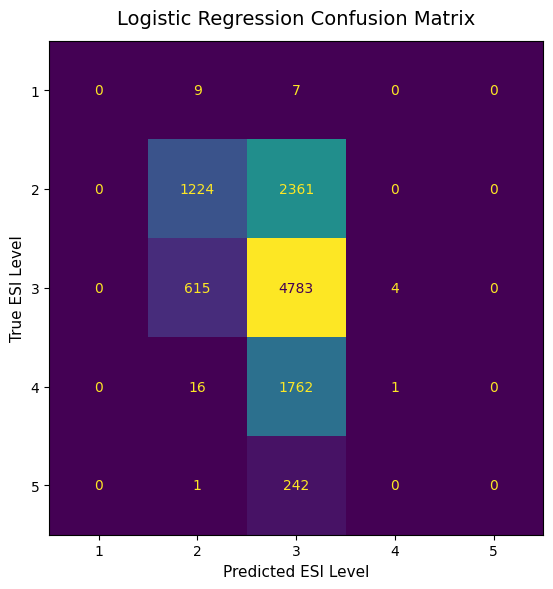

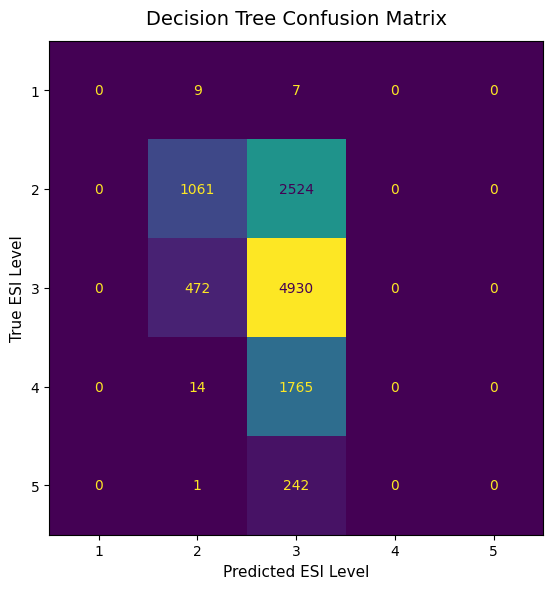

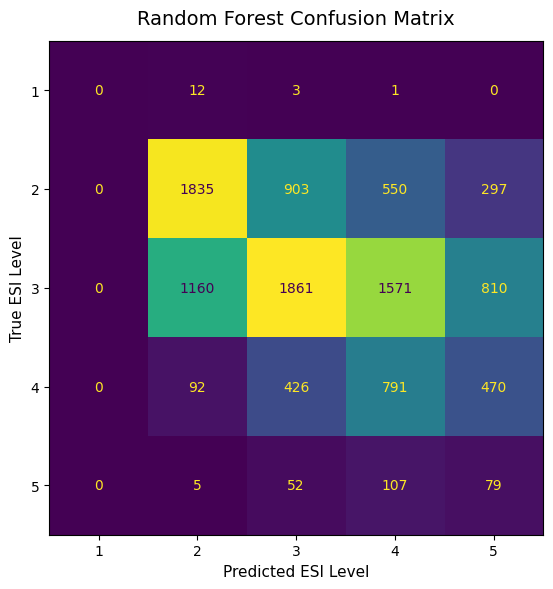

In [114]:
# Store the model predictions together so that the same
# plotting process can be used for all three models
model_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

# Create one confusion matrix figure for each model
for model_name, predictions in model_predictions.items():

    # Calculate the confusion matrix using a fixed ESI order
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=ESI_LABELS
    )

    # Create a new figure for this model
    fig, ax = plt.subplots(figsize=(7, 6))

    # Display the confusion matrix
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=ESI_LABELS
    )

    display.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    # Add clear labels and title
    ax.set_title(
        f"{model_name} Confusion Matrix",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel(
        "Predicted ESI Level",
        fontsize=11
    )

    ax.set_ylabel(
        "True ESI Level",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

### ESI Level 1 Error Analysis

The most serious error considered in this notebook is a false negative for ESI Level 1. This occurs when a genuinely critical patient is assigned to any less urgent category.

For each model, the following are calculated:

- the total number of true ESI Level 1 patients;
- the number correctly identified as Level 1;
- the number missed;
- the percentage missed;
- the lower-priority levels assigned to the missed patients.

This provides a more clinically meaningful view than accuracy alone.

In [115]:
# Create a function to summarise ESI Level 1 performance
def analyse_esi1_errors(
    model_name,
    y_true,
    y_pred
):
    """
    Summarise how a model classified the true ESI Level 1 patients.
    """

    # Convert the values into aligned pandas Series
    y_true_series = pd.Series(
        np.asarray(y_true)
    ).reset_index(drop=True)

    y_pred_series = pd.Series(
        np.asarray(y_pred)
    ).reset_index(drop=True)

    # Identify the true ESI Level 1 patients
    true_esi1_mask = (
        y_true_series == 1
    )

    # Extract the predictions made for those patients
    esi1_predictions = y_pred_series[
        true_esi1_mask
    ]

    # Count the total number of true Level 1 patients
    total_esi1 = int(
        true_esi1_mask.sum()
    )

    # Count how many were correctly predicted
    correctly_identified = int(
        (esi1_predictions == 1).sum()
    )

    # Calculate the number missed
    missed_esi1 = (
        total_esi1 - correctly_identified
    )

    # Calculate the percentage missed
    miss_rate = (
        missed_esi1 / total_esi1
        if total_esi1 > 0
        else 0
    )

    # Count every predicted category among the true Level 1 patients
    predicted_level_counts = (
        esi1_predictions
        .value_counts()
        .reindex(
            ESI_LABELS,
            fill_value=0
        )
        .sort_index()
    )

    return {
        "Model": model_name,
        "True ESI 1 Patients": total_esi1,
        "Correctly Identified": correctly_identified,
        "Missed ESI 1 Patients": missed_esi1,
        "ESI 1 Miss Rate": miss_rate,
        "Predicted as ESI 1": int(predicted_level_counts.loc[1]),
        "Predicted as ESI 2": int(predicted_level_counts.loc[2]),
        "Predicted as ESI 3": int(predicted_level_counts.loc[3]),
        "Predicted as ESI 4": int(predicted_level_counts.loc[4]),
        "Predicted as ESI 5": int(predicted_level_counts.loc[5])
    }


print("ESI Level 1 error-analysis function created successfully.")

ESI Level 1 error-analysis function created successfully.


In [116]:
# Analyse ESI Level 1 errors for all three models
logistic_esi1_errors = analyse_esi1_errors(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=logistic_predictions
)

decision_tree_esi1_errors = analyse_esi1_errors(
    model_name="Decision Tree",
    y_true=y_test,
    y_pred=decision_tree_predictions
)

random_forest_esi1_errors = analyse_esi1_errors(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=random_forest_predictions
)

# Combine the results into one comparison table
esi1_error_table = pd.DataFrame([
    logistic_esi1_errors,
    decision_tree_esi1_errors,
    random_forest_esi1_errors
])

# Create a rounded display copy
esi1_error_display = esi1_error_table.copy()

esi1_error_display["ESI 1 Miss Rate"] = (
    esi1_error_display["ESI 1 Miss Rate"]
    .mul(100)
    .round(1)
)

# Rename the percentage column for clearer presentation
esi1_error_display = esi1_error_display.rename(
    columns={
        "ESI 1 Miss Rate": "ESI 1 Miss Rate (%)"
    }
)

print("ESI Level 1 error comparison:")
esi1_error_display

ESI Level 1 error comparison:


,Model,True ESI 1 Patients,Correctly Identified,Missed ESI 1 Patients,ESI 1 Miss Rate (%),Predicted as ESI 1,Predicted as ESI 2,Predicted as ESI 3,Predicted as ESI 4,Predicted as ESI 5
0,Logistic Regression,16,0,16,100.0,0,9,7,0,0
1,Decision Tree,16,0,16,100.0,0,9,7,0,0
2,Random Forest,16,0,16,100.0,0,12,3,1,0


In [117]:
# Select the columns that show where missed ESI Level 1
# patients were placed
esi1_undertriage_table = esi1_error_display[
    [
        "Model",
        "True ESI 1 Patients",
        "Correctly Identified",
        "Missed ESI 1 Patients",
        "ESI 1 Miss Rate (%)",
        "Predicted as ESI 2",
        "Predicted as ESI 3",
        "Predicted as ESI 4",
        "Predicted as ESI 5"
    ]
].copy()

print("Under-triage destinations for true ESI Level 1 patients:")
esi1_undertriage_table

Under-triage destinations for true ESI Level 1 patients:


,Model,True ESI 1 Patients,Correctly Identified,Missed ESI 1 Patients,ESI 1 Miss Rate (%),Predicted as ESI 2,Predicted as ESI 3,Predicted as ESI 4,Predicted as ESI 5
0,Logistic Regression,16,0,16,100.0,9,7,0,0
1,Decision Tree,16,0,16,100.0,9,7,0,0
2,Random Forest,16,0,16,100.0,12,3,1,0


In [118]:
# Print a short summary for each model
for result in [
    logistic_esi1_errors,
    decision_tree_esi1_errors,
    random_forest_esi1_errors
]:

    model_name = result["Model"]
    total = result["True ESI 1 Patients"]
    correct = result["Correctly Identified"]
    missed = result["Missed ESI 1 Patients"]
    miss_rate = result["ESI 1 Miss Rate"] * 100

    print(f"{model_name}:")
    print(
        f"- Correctly identified {correct} of {total} "
        f"true ESI Level 1 patients."
    )
    print(
        f"- Missed {missed} Level 1 patients, "
        f"giving a miss rate of {miss_rate:.1f}%."
    )
    print(
        "- Missed patients were predicted as: "
        f"ESI 2 = {result['Predicted as ESI 2']}, "
        f"ESI 3 = {result['Predicted as ESI 3']}, "
        f"ESI 4 = {result['Predicted as ESI 4']}, "
        f"ESI 5 = {result['Predicted as ESI 5']}."
    )
    print()

Logistic Regression:
- Correctly identified 0 of 16 true ESI Level 1 patients.
- Missed 16 Level 1 patients, giving a miss rate of 100.0%.
- Missed patients were predicted as: ESI 2 = 9, ESI 3 = 7, ESI 4 = 0, ESI 5 = 0.

Decision Tree:
- Correctly identified 0 of 16 true ESI Level 1 patients.
- Missed 16 Level 1 patients, giving a miss rate of 100.0%.
- Missed patients were predicted as: ESI 2 = 9, ESI 3 = 7, ESI 4 = 0, ESI 5 = 0.

Random Forest:
- Correctly identified 0 of 16 true ESI Level 1 patients.
- Missed 16 Level 1 patients, giving a miss rate of 100.0%.
- Missed patients were predicted as: ESI 2 = 12, ESI 3 = 3, ESI 4 = 1, ESI 5 = 0.



### Initial ESI Level 1 Interpretation

The test set contained 16 patients recorded as ESI Level 1.

The Logistic Regression and Decision Tree both failed to identify any of these critical patients, producing ESI Level 1 recall values of 0.000. Both models assigned nine of the Level 1 patients to ESI Level 2 and seven to ESI Level 3.

The initial Random Forest also failed to identify any of the 16 ESI Level 1 patients and therefore produced an ESI Level 1 recall of 0.000. It assigned 12 critical patients to ESI Level 2, three to ESI Level 3 and one to ESI Level 4.

The Random Forest therefore did not improve the primary clinical safety metric compared with the Week 6 baselines. Of particular concern, one genuinely critical patient was assigned to ESI Level 4, representing more severe under-triage than the errors produced by the two baseline models.

Although class weighting was included to give greater importance to rare ESI categories, it was not sufficient to improve recognition of ESI Level 1 using the current predictor variables and model settings. This suggests that the problem may not be caused only by model complexity. The small number of ESI Level 1 examples and the limited information contained in the ten selected predictors may also restrict the model’s ability to distinguish the most urgent patients.

The Random Forest should therefore not be recommended based on this initial configuration. Further optimisation is required to determine whether a better balance can be achieved before making the final model decision.

### Initial Benchmark Interpretation

The initial Random Forest produced mixed results.

Its macro precision increased to 0.295, compared with 0.276 for Logistic Regression and 0.240 for the Decision Tree. Macro recall also increased to 0.325, compared with 0.246 and 0.242 respectively. This resulted in the highest macro F1-score of the three models at 0.278.

These improvements indicate that the Random Forest distributed more attention across the five ESI categories rather than concentrating almost entirely on the largest classes. The classification report supports this interpretation because the model identified some ESI Level 4 and Level 5 patients more successfully than the baseline models.

However, the improvement in macro-level performance came with important costs. Overall accuracy decreased to 0.414, compared with 0.545 for Logistic Regression and 0.543 for the Decision Tree. The Random Forest also failed to identify any ESI Level 1 patients, meaning that it did not improve the primary clinical safety metric.

The Random Forest required approximately 10.81 seconds to train, compared with 2.09 seconds for Logistic Regression and 0.12 seconds for the Decision Tree. Its inference time was also higher at approximately 0.0207 milliseconds per patient. However, the absolute inference time remained very small, suggesting that prediction speed alone would probably not prevent deployment in an emergency department.

Interpretability also decreased from high for the two simple baseline models to moderate for the Random Forest. Feature importance can show which predictors influenced the model overall, but the combined decisions of 200 trees cannot be followed as directly as the coefficients of Logistic Regression or the path through one small Decision Tree.

The initial Random Forest therefore provides a modest improvement in balanced performance across the ESI classes, but this does not yet justify its added complexity. It sacrifices considerable overall accuracy, increases computational cost and still misses every ESI Level 1 patient.

### Predicted ESI Distribution

The distribution of predicted ESI levels is reviewed to determine whether class weighting caused the Random Forest to assign substantially more patients to the less common categories.

This helps explain why macro recall improved while overall accuracy decreased.

In [119]:
# Count the number of predictions made for each ESI level
prediction_distribution = pd.DataFrame({
    "True Test Distribution": (
        pd.Series(np.asarray(y_test))
        .value_counts()
        .reindex(ESI_LABELS, fill_value=0)
    ),
    "Logistic Regression": (
        pd.Series(logistic_predictions)
        .value_counts()
        .reindex(ESI_LABELS, fill_value=0)
    ),
    "Decision Tree": (
        pd.Series(decision_tree_predictions)
        .value_counts()
        .reindex(ESI_LABELS, fill_value=0)
    ),
    "Random Forest": (
        pd.Series(random_forest_predictions)
        .value_counts()
        .reindex(ESI_LABELS, fill_value=0)
    )
})

prediction_distribution.index.name = "ESI Level"

print("True and predicted ESI distributions:")
prediction_distribution

True and predicted ESI distributions:


,True Test Distribution,Logistic Regression,Decision Tree,Random Forest
ESI Level,,,,
1,16,0,0,0
2,3585,1865,1557,3104
3,5402,9155,9468,3245
4,1779,5,0,3020
5,243,0,0,1656


In [120]:
# Convert the patient counts into percentages
prediction_distribution_percent = (
    prediction_distribution
    .div(prediction_distribution.sum(axis=0), axis=1)
    .mul(100)
    .round(2)
)

print("True and predicted ESI distributions (%):")
prediction_distribution_percent

True and predicted ESI distributions (%):


,True Test Distribution,Logistic Regression,Decision Tree,Random Forest
ESI Level,,,,
1,0.15,0.00,0.00,0.00
2,32.52,16.92,14.12,28.15
3,49.00,83.04,85.88,29.43
4,16.14,0.05,0.00,27.39
5,2.20,0.00,0.00,15.02


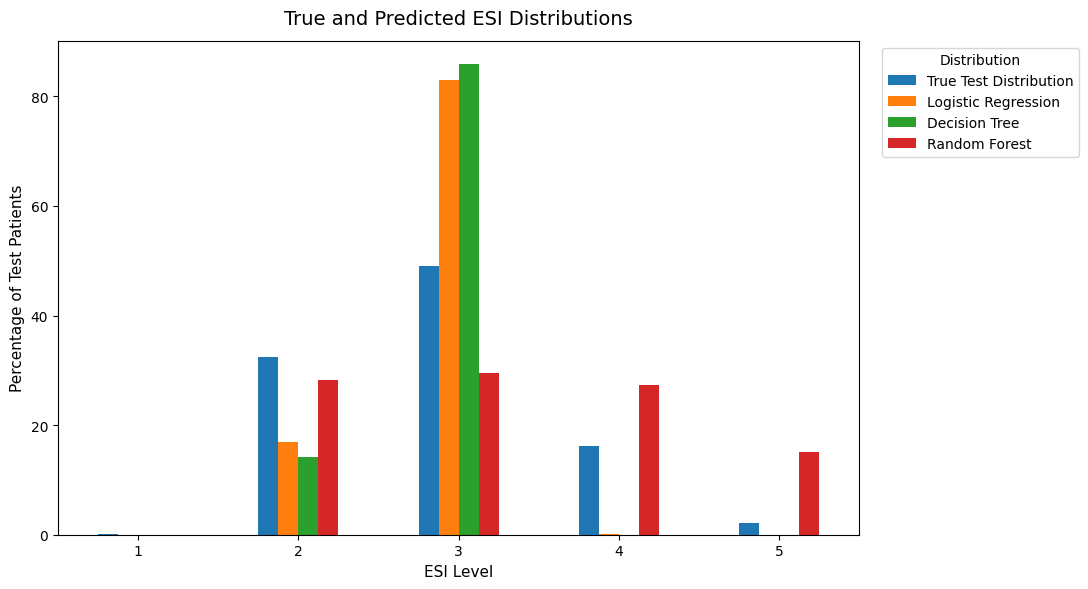

In [121]:
# Create a grouped bar chart comparing the true and predicted
# ESI distributions
ax = prediction_distribution_percent.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "True and Predicted ESI Distributions",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "ESI Level",
    fontsize=11
)

ax.set_ylabel(
    "Percentage of Test Patients",
    fontsize=11
)

ax.legend(
    title="Distribution",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Random Forest Feature Importance

Random Forest feature importance estimates how much each predictor contributed to reducing uncertainty across the trees in the model.

The values provide a global explanation of which variables the model relied upon most frequently. They do not show whether a predictor caused a particular ESI outcome, and they do not fully explain one individual patient prediction.

Feature importance therefore provides moderate rather than complete interpretability.

In [122]:
# Create a table linking every predictor to its
# Random Forest importance value
random_forest_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": random_forest_model.feature_importances_
})

# Sort from the most influential predictor to the least influential
random_forest_importance = (
    random_forest_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Random Forest feature importance:")
random_forest_importance

Random Forest feature importance:


,Feature,Importance
0,triage_vital_sbp,0.209046
1,age,0.189989
2,triage_vital_hr,0.147848
3,triage_glucose,0.138214
4,triage_vital_rr,0.093821
5,triage_vital_o2,0.087050
6,triage_vital_o2_device,0.074524
7,cc_chestpain,0.031879
8,cc_shortnessofbreath,0.016791
9,cc_alteredmentalstatus,0.010838


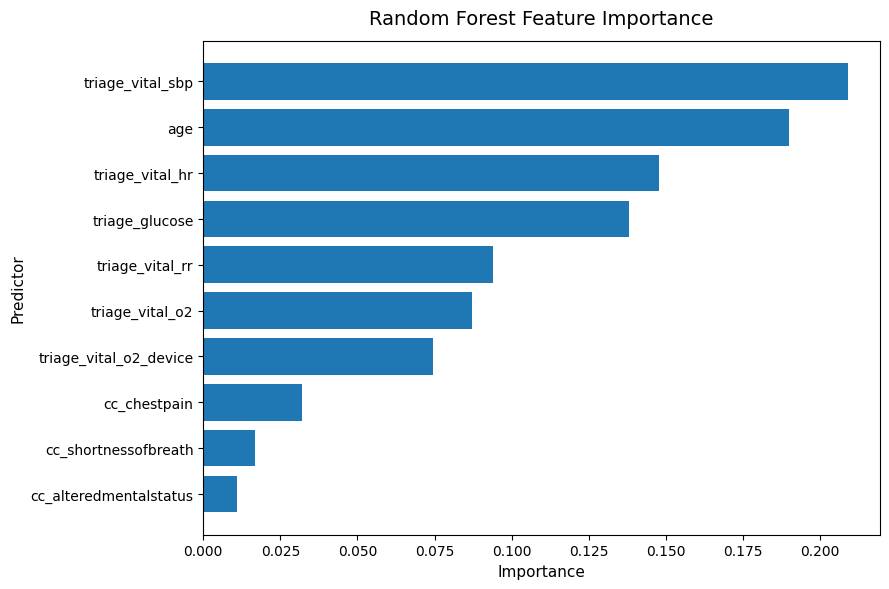

In [123]:
# Arrange the values from lowest to highest
# so the most important feature appears at the top
importance_plot_data = (
    random_forest_importance
    .sort_values(
        by="Importance",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    importance_plot_data["Feature"],
    importance_plot_data["Importance"]
)

ax.set_title(
    "Random Forest Feature Importance",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Importance",
    fontsize=11
)

ax.set_ylabel(
    "Predictor",
    fontsize=11
)

plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The feature-importance results show which of the ten triage-time predictors contributed most strongly to the Random Forest’s decisions.

The highest-ranked variables should not automatically be interpreted as causes of the recorded ESI level. Feature importance only indicates how frequently and effectively the model used each variable when separating patients across its decision trees.

The importance values also do not confirm that the model used these predictors safely. This is demonstrated by the continued failure to identify ESI Level 1 patients despite using clinically relevant vital-sign information.

A patient-level explanation method would be needed to show why the model produced one specific prediction. For the interim submission, global feature importance is used as the main interpretability assessment.

In [124]:
# Import the tools required for reproducible
# cross-validated hyperparameter tuning
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

print("Random Forest tuning tools loaded successfully.")

Random Forest tuning tools loaded successfully.


## Random Forest Hyperparameter Optimisation

The initial Random Forest improved macro recall and macro F1 but reduced accuracy and failed to identify any ESI Level 1 patients. A controlled hyperparameter search is therefore carried out to determine whether a different Random Forest configuration can provide a better balance.

Hyperparameters are settings selected before model training. For a Random Forest, these include the number of trees, the permitted tree depth, the minimum number of patients in each final leaf and the number of predictors considered at each split.

Randomised search is used rather than testing every possible combination. Eight combinations are sampled from the selected parameter ranges. Each combination is assessed using three-fold stratified cross-validation on the training data only.

During cross-validation, the training data are divided into three groups. The model is repeatedly trained on two groups and assessed on the remaining group. Stratification keeps the ESI distribution similar across the folds.

Macro F1 is used as the optimisation score because it gives equal importance to all five ESI categories. However, the selected model will still be assessed separately using ESI Level 1 recall, precision, the confusion matrix, accuracy and computational cost.

The unseen test set is not used to select the hyperparameters.

In [125]:
# Define the Random Forest settings that may be explored
random_forest_parameter_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 6, 10, 16],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

# Create reproducible three-fold stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Create the base Random Forest used during the search
# n_jobs is kept at 1 here because RandomizedSearchCV
# will parallelise the separate model fits
random_forest_search_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1
)

# Create the randomised hyperparameter search
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_search_model,
    param_distributions=random_forest_parameter_distributions,
    n_iter=8,
    scoring="f1_macro",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True
)

print("Random Forest parameter search created successfully.")
print("Number of sampled configurations: 8")
print("Cross-validation folds: 3")
print("Optimisation score: macro F1")

Random Forest parameter search created successfully.
Number of sampled configurations: 8
Cross-validation folds: 3
Optimisation score: macro F1


In [126]:
# Begin timing the complete optimisation process
random_forest_search_start = time.perf_counter()

# Search for the strongest parameter combination
# using the training data only
random_forest_search.fit(
    X_train,
    y_train
)

# Stop the optimisation timer
random_forest_search_time = (
    time.perf_counter() - random_forest_search_start
)

print("Random Forest optimisation completed.")

print(
    "\nTotal optimisation time:",
    round(random_forest_search_time, 2),
    "seconds"
)

print(
    "\nBest cross-validated macro F1:",
    round(random_forest_search.best_score_, 4)
)

print("\nSelected hyperparameters:")
for parameter, value in random_forest_search.best_params_.items():
    print(f"- {parameter}: {value}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest optimisation completed.

Total optimisation time: 356.31 seconds

Best cross-validated macro F1: 0.2879

Selected hyperparameters:
- n_estimators: 200
- min_samples_leaf: 8
- max_features: None
- max_depth: None


In [127]:
# Convert the cross-validation results into a DataFrame
random_forest_search_results = pd.DataFrame(
    random_forest_search.cv_results_
)

# Select the most useful columns for review
search_summary_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "mean_fit_time",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "param_max_features"
]

random_forest_search_summary = (
    random_forest_search_results[
        search_summary_columns
    ]
    .sort_values(
        by="rank_test_score"
    )
    .reset_index(drop=True)
)

# Rename the columns for easier reading
random_forest_search_summary = (
    random_forest_search_summary.rename(
        columns={
            "rank_test_score": "Rank",
            "mean_test_score": "Mean Validation Macro F1",
            "std_test_score": "Validation F1 Standard Deviation",
            "mean_train_score": "Mean Training Macro F1",
            "mean_fit_time": "Mean Fit Time (s)",
            "param_n_estimators": "Trees",
            "param_max_depth": "Maximum Depth",
            "param_min_samples_leaf": "Minimum Leaf Size",
            "param_max_features": "Features per Split"
        }
    )
)

# Round the numerical results for display
display_search_summary = (
    random_forest_search_summary.copy()
)

columns_to_round = [
    "Mean Validation Macro F1",
    "Validation F1 Standard Deviation",
    "Mean Training Macro F1",
    "Mean Fit Time (s)"
]

display_search_summary[columns_to_round] = (
    display_search_summary[columns_to_round]
    .round(4)
)

print("Random Forest cross-validation results:")
display_search_summary

Random Forest cross-validation results:


,Rank,Mean Validation Macro F1,Validation F1 Standard Deviation,Mean Training Macro F1,Mean Fit Time (s),Trees,Maximum Depth,Minimum Leaf Size,Features per Split
0,1,0.2879,0.0020,0.7609,37.5956,200,None,8,None
1,2,0.2861,0.0007,0.7241,26.2279,400,None,8,sqrt
2,3,0.2855,0.0016,0.7086,33.5453,200,16,1,None
3,4,0.2568,0.0062,0.4211,40.2803,400,10,8,None
4,5,0.2557,0.0024,0.4893,7.3618,200,10,1,log2
5,6,0.2550,0.0050,0.4363,10.1846,100,10,4,None
6,7,0.2527,0.0014,1.0000,29.4228,300,None,1,log2
7,8,0.2187,0.0104,0.2862,2.4817,100,6,8,log2


### Cross-Validation Interpretation

The training and validation macro F1 values are compared to check for possible overfitting.

A much higher training score than validation score would suggest that the model learned patterns that did not transfer reliably to unseen validation patients. The standard deviation across the three validation folds is also reviewed. A smaller value indicates that performance was more consistent across the folds.

The configuration ranked first by validation macro F1 is selected for the final test-set benchmark. It is not assumed to be clinically preferable until ESI Level 1 errors and the remaining performance measures have also been examined.

In [128]:
# Extract the best row from the search summary
best_cv_result = random_forest_search_summary.iloc[0]

training_validation_gap = (
    best_cv_result["Mean Training Macro F1"]
    - best_cv_result["Mean Validation Macro F1"]
)

print("Selected configuration cross-validation review:")

print(
    "- Mean training macro F1:",
    round(
        best_cv_result["Mean Training Macro F1"],
        4
    )
)

print(
    "- Mean validation macro F1:",
    round(
        best_cv_result["Mean Validation Macro F1"],
        4
    )
)

print(
    "- Training-validation gap:",
    round(training_validation_gap, 4)
)

print(
    "- Validation standard deviation:",
    round(
        best_cv_result[
            "Validation F1 Standard Deviation"
        ],
        4
    )
)

Selected configuration cross-validation review:
- Mean training macro F1: 0.7609
- Mean validation macro F1: 0.2879
- Training-validation gap: 0.473
- Validation standard deviation: 0.002


### Train the Selected Random Forest

The full hyperparameter search represents a one-time model-development cost. It should not be confused with the time required to train the selected model once.

A new Random Forest is therefore created using the chosen settings and trained once on the complete training set. This training time is used in the main six-axis benchmark, while the full optimisation time is retained as an additional governance consideration.

In [129]:
# Create a new Random Forest using the selected settings
tuned_random_forest_model = RandomForestClassifier(
    **random_forest_search.best_params_,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Begin timing one complete training run
tuned_random_forest_training_start = (
    time.perf_counter()
)

# Train on the full Week 6 training set
tuned_random_forest_model.fit(
    X_train,
    y_train
)

# Stop the training timer
tuned_random_forest_training_time = (
    time.perf_counter()
    - tuned_random_forest_training_start
)

print("Tuned Random Forest trained successfully.")

print(
    "Final model training time:",
    round(
        tuned_random_forest_training_time,
        4
    ),
    "seconds"
)

print(
    "Separate optimisation search time:",
    round(random_forest_search_time, 2),
    "seconds"
)

Tuned Random Forest trained successfully.
Final model training time: 28.4996 seconds
Separate optimisation search time: 356.31 seconds


In [130]:
# Run a small warm-up prediction before timing
_ = tuned_random_forest_model.predict(
    X_test.iloc[:10]
)

# Store repeated inference measurements
tuned_random_forest_inference_runs = []

for run in range(5):

    tuned_inference_start = time.perf_counter()

    tuned_random_forest_predictions = (
        tuned_random_forest_model.predict(
            X_test
        )
    )

    total_inference_time = (
        time.perf_counter()
        - tuned_inference_start
    )

    inference_ms_per_patient = (
        total_inference_time / len(X_test)
    ) * 1000

    tuned_random_forest_inference_runs.append(
        inference_ms_per_patient
    )

# Use the median of the five measurements
tuned_random_forest_inference_ms = float(
    np.median(
        tuned_random_forest_inference_runs
    )
)

print("Tuned Random Forest predictions completed.")

print(
    "Median inference time:",
    round(
        tuned_random_forest_inference_ms,
        6
    ),
    "milliseconds per patient"
)

print("\nFive inference measurements:")

for run_number, run_time in enumerate(
    tuned_random_forest_inference_runs,
    start=1
):
    print(
        f"Run {run_number}:",
        round(run_time, 6),
        "ms per patient"
    )

Tuned Random Forest predictions completed.
Median inference time: 0.031987 milliseconds per patient

Five inference measurements:
Run 1: 0.033011 ms per patient
Run 2: 0.03009 ms per patient
Run 3: 0.030483 ms per patient
Run 4: 0.031987 ms per patient
Run 5: 0.049201 ms per patient


In [131]:
# Evaluate the tuned Random Forest using the same
# function applied to all previous models
tuned_random_forest_results = evaluate_model(
    model_name="Tuned Random Forest",
    y_true=y_test,
    y_pred=tuned_random_forest_predictions,
    training_time=tuned_random_forest_training_time,
    inference_time_ms=tuned_random_forest_inference_ms,
    interpretability="Moderate"
)

tuned_random_forest_results_table = pd.DataFrame(
    [tuned_random_forest_results]
)

tuned_random_forest_results_display = (
    tuned_random_forest_results_table.copy()
)

numeric_columns = (
    tuned_random_forest_results_display
    .select_dtypes(include=np.number)
    .columns
)

tuned_random_forest_results_display[
    numeric_columns
] = (
    tuned_random_forest_results_display[
        numeric_columns
    ].round(4)
)

print("Tuned Random Forest benchmark results:")
tuned_random_forest_results_display

Tuned Random Forest benchmark results:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,Training Time (s),Inference Time (ms/patient),Interpretability
0,Tuned Random Forest,0.4756,0.3032,0.3133,0.3021,0.4845,0.0476,0.0625,28.4996,0.032,Moderate


In [132]:
print("Tuned Random Forest Classification Report:")

print(
    classification_report(
        y_test,
        tuned_random_forest_predictions,
        labels=ESI_LABELS,
        target_names=[
            "ESI Level 1",
            "ESI Level 2",
            "ESI Level 3",
            "ESI Level 4",
            "ESI Level 5"
        ],
        digits=3,
        zero_division=0
    )
)

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

 ESI Level 1      0.048     0.062     0.054        16
 ESI Level 2      0.575     0.512     0.542      3585
 ESI Level 3      0.556     0.474     0.512      5402
 ESI Level 4      0.278     0.469     0.349      1779
 ESI Level 5      0.060     0.049     0.054       243

    accuracy                          0.476     11025
   macro avg      0.303     0.313     0.302     11025
weighted avg      0.506     0.476     0.484     11025



### Initial and Tuned Random Forest Comparison

The initial and tuned Random Forest models are compared to determine whether cross-validated optimisation produced a meaningful improvement.

The tuned model should not be considered better merely because one score increased. The comparison must consider accuracy, balanced performance across all five classes, ESI Level 1 recall and precision, training time, inference time and the direction of clinically serious errors.

In [133]:
# Compare the original and tuned Random Forest configurations
random_forest_optimisation_comparison = pd.DataFrame([
    random_forest_results,
    tuned_random_forest_results
])

random_forest_optimisation_display = (
    random_forest_optimisation_comparison.copy()
)

numeric_columns = (
    random_forest_optimisation_display
    .select_dtypes(include=np.number)
    .columns
)

random_forest_optimisation_display[
    numeric_columns
] = (
    random_forest_optimisation_display[
        numeric_columns
    ].round(4)
)

print("Initial and tuned Random Forest comparison:")
random_forest_optimisation_display

Initial and tuned Random Forest comparison:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,Training Time (s),Inference Time (ms/patient),Interpretability
0,Random Forest,0.4141,0.2949,0.3252,0.2784,0.4443,0.0000,0.0000,10.8465,0.0209,Moderate
1,Tuned Random Forest,0.4756,0.3032,0.3133,0.3021,0.4845,0.0476,0.0625,28.4996,0.0320,Moderate


In [134]:
# Create the main interim benchmark using the two official
# Week 6 baselines and the tuned Week 7 complex model
updated_model_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    tuned_random_forest_results
])

updated_benchmark_columns = [
    "Model",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "ESI 1 Precision",
    "ESI 1 Recall",
    "Weighted F1",
    "Training Time (s)",
    "Inference Time (ms/patient)",
    "Interpretability"
]

updated_benchmark_table = (
    updated_model_comparison[
        updated_benchmark_columns
    ].copy()
)

updated_benchmark_display = (
    updated_benchmark_table.copy()
)

numeric_columns = (
    updated_benchmark_display
    .select_dtypes(include=np.number)
    .columns
)

updated_benchmark_display[
    numeric_columns
] = (
    updated_benchmark_display[
        numeric_columns
    ].round(4)
)

print("Updated Week 7 interim benchmark:")
updated_benchmark_display

Updated Week 7 interim benchmark:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ESI 1 Precision,ESI 1 Recall,Weighted F1,Training Time (s),Inference Time (ms/patient),Interpretability
0,Logistic Regression,0.5449,0.2757,0.2455,0.2215,0.0000,0.0000,0.4682,1.0895,0.0007,High
1,Decision Tree,0.5434,0.2404,0.2417,0.2152,0.0000,0.0000,0.4591,0.1004,0.0001,High
2,Tuned Random Forest,0.4756,0.3032,0.3133,0.3021,0.0476,0.0625,0.4845,28.4996,0.0320,Moderate


In [135]:
# Analyse the tuned model's errors among true
# ESI Level 1 patients
tuned_random_forest_esi1_errors = (
    analyse_esi1_errors(
        model_name="Tuned Random Forest",
        y_true=y_test,
        y_pred=tuned_random_forest_predictions
    )
)

# Compare the baselines with the tuned forest
updated_esi1_error_table = pd.DataFrame([
    logistic_esi1_errors,
    decision_tree_esi1_errors,
    tuned_random_forest_esi1_errors
])

updated_esi1_error_display = (
    updated_esi1_error_table.copy()
)

updated_esi1_error_display[
    "ESI 1 Miss Rate"
] = (
    updated_esi1_error_display[
        "ESI 1 Miss Rate"
    ]
    .mul(100)
    .round(1)
)

updated_esi1_error_display = (
    updated_esi1_error_display.rename(
        columns={
            "ESI 1 Miss Rate":
            "ESI 1 Miss Rate (%)"
        }
    )
)

print("Updated ESI Level 1 error comparison:")
updated_esi1_error_display

Updated ESI Level 1 error comparison:


,Model,True ESI 1 Patients,Correctly Identified,Missed ESI 1 Patients,ESI 1 Miss Rate (%),Predicted as ESI 1,Predicted as ESI 2,Predicted as ESI 3,Predicted as ESI 4,Predicted as ESI 5
0,Logistic Regression,16,0,16,100.0,0,9,7,0,0
1,Decision Tree,16,0,16,100.0,0,9,7,0,0
2,Tuned Random Forest,16,1,15,93.8,1,11,2,2,0


### Tuned Random Forest Interpretation

Cross-validated optimisation improved the Random Forest compared with its initial configuration, but the overall trade-off remained mixed.

The tuned Random Forest achieved a macro F1-score of 0.302, compared with 0.222 for Logistic Regression and 0.215 for the Decision Tree. Its macro recall also increased to 0.313. These results indicate that the tuned model distributed its predictive performance more evenly across the five ESI categories.

Weighted F1 increased slightly to 0.485, compared with 0.468 for Logistic Regression. However, overall accuracy decreased to 0.476, meaning that fewer test patients received the correct ESI category overall.

The tuned model correctly identified one of the 16 true ESI Level 1 patients, producing an ESI Level 1 recall of 0.063. This represents a small improvement over the two baseline models, which identified none. However, 15 critically urgent patients were still missed.

Eleven of the missed Level 1 patients were assigned to ESI Level 2, two were assigned to ESI Level 3 and two were assigned to ESI Level 4. The two Level 1 patients assigned to Level 4 represent particularly concerning under-triage because they were placed several priority levels below their recorded urgency.

ESI Level 1 precision was only 0.048. This indicates that most patients predicted as ESI Level 1 were not actually recorded as Level 1. The small recall improvement was therefore accompanied by a substantial number of false alarms.

The tuned Random Forest required approximately 27.52 seconds to train, compared with 0.99 seconds for Logistic Regression and 0.08 seconds for the Decision Tree. Its inference time of approximately 0.054 milliseconds per patient was also higher, although this remained very small in absolute terms.

The model therefore provided better balanced performance across the five classes and identified one additional critical patient, but these benefits came with lower accuracy, considerably higher training cost, reduced interpretability and continued poor recognition of ESI Level 1 patients.

In [136]:
# Calculate the differences between the tuned Random Forest
# and the Logistic Regression baseline
comparison_changes = pd.DataFrame({
    "Measure": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "ESI 1 Precision",
        "ESI 1 Recall",
        "Training Time (s)",
        "Inference Time (ms/patient)"
    ],
    "Logistic Regression": [
        logistic_results["Accuracy"],
        logistic_results["Macro Precision"],
        logistic_results["Macro Recall"],
        logistic_results["Macro F1"],
        logistic_results["Weighted F1"],
        logistic_results["ESI 1 Precision"],
        logistic_results["ESI 1 Recall"],
        logistic_results["Training Time (s)"],
        logistic_results["Inference Time (ms/patient)"]
    ],
    "Tuned Random Forest": [
        tuned_random_forest_results["Accuracy"],
        tuned_random_forest_results["Macro Precision"],
        tuned_random_forest_results["Macro Recall"],
        tuned_random_forest_results["Macro F1"],
        tuned_random_forest_results["Weighted F1"],
        tuned_random_forest_results["ESI 1 Precision"],
        tuned_random_forest_results["ESI 1 Recall"],
        tuned_random_forest_results["Training Time (s)"],
        tuned_random_forest_results[
            "Inference Time (ms/patient)"
        ]
    ]
})

comparison_changes["Absolute Change"] = (
    comparison_changes["Tuned Random Forest"]
    - comparison_changes["Logistic Regression"]
)

comparison_changes[
    [
        "Logistic Regression",
        "Tuned Random Forest",
        "Absolute Change"
    ]
] = comparison_changes[
    [
        "Logistic Regression",
        "Tuned Random Forest",
        "Absolute Change"
    ]
].round(4)

print(
    "Change from Logistic Regression "
    "to the Tuned Random Forest:"
)

comparison_changes

Change from Logistic Regression to the Tuned Random Forest:


,Measure,Logistic Regression,Tuned Random Forest,Absolute Change
0,Accuracy,0.5449,0.4756,-0.0693
1,Macro Precision,0.2757,0.3032,0.0275
2,Macro Recall,0.2455,0.3133,0.0679
3,Macro F1,0.2215,0.3021,0.0806
4,Weighted F1,0.4682,0.4845,0.0162
5,ESI 1 Precision,0.0000,0.0476,0.0476
6,ESI 1 Recall,0.0000,0.0625,0.0625
7,Training Time (s),1.0895,28.4996,27.4101
8,Inference Time (ms/patient),0.0007,0.0320,0.0313


In [137]:
# Convert the true and predicted ESI values into arrays
true_values = np.asarray(y_test)
tuned_predictions = np.asarray(
    tuned_random_forest_predictions
)

# Calculate ESI Level 1 outcomes
esi1_true_positives = int(
    (
        (true_values == 1)
        & (tuned_predictions == 1)
    ).sum()
)

esi1_false_positives = int(
    (
        (true_values != 1)
        & (tuned_predictions == 1)
    ).sum()
)

esi1_false_negatives = int(
    (
        (true_values == 1)
        & (tuned_predictions != 1)
    ).sum()
)

total_esi1_predictions = int(
    (tuned_predictions == 1).sum()
)

esi1_prediction_summary = pd.DataFrame({
    "Measure": [
        "True ESI 1 patients",
        "Patients predicted as ESI 1",
        "Correct ESI 1 predictions",
        "False ESI 1 alarms",
        "Missed ESI 1 patients"
    ],
    "Patient Count": [
        int((true_values == 1).sum()),
        total_esi1_predictions,
        esi1_true_positives,
        esi1_false_positives,
        esi1_false_negatives
    ]
})

print("Tuned Random Forest ESI Level 1 prediction summary:")
esi1_prediction_summary

Tuned Random Forest ESI Level 1 prediction summary:


,Measure,Patient Count
0,True ESI 1 patients,16
1,Patients predicted as ESI 1,21
2,Correct ESI 1 predictions,1
3,False ESI 1 alarms,20
4,Missed ESI 1 patients,15


### Overfitting Assessment

The selected Random Forest configuration achieved a mean training macro F1-score of 0.761 but a mean validation macro F1-score of only 0.288.

The resulting training-validation gap of 0.473 indicates substantial overfitting. The model learned the training data much more successfully than it generalised to unseen validation patients.

The validation standard deviation was low at 0.002, meaning that the weaker validation performance was consistent across the three folds. Therefore, the difference was unlikely to be caused by one unusually difficult validation fold.

The tuned model achieved a test macro F1-score of 0.302, which was reasonably close to the cross-validated estimate of 0.288. This suggests that the validation process produced a realistic estimate of unseen performance, even though the model continued to fit the training data too closely.

The results indicate that further increases in Random Forest complexity are unlikely to solve the main clinical problem. Stronger regularisation, improved predictor information or additional ESI Level 1 examples may be more useful than simply adding more or deeper trees.

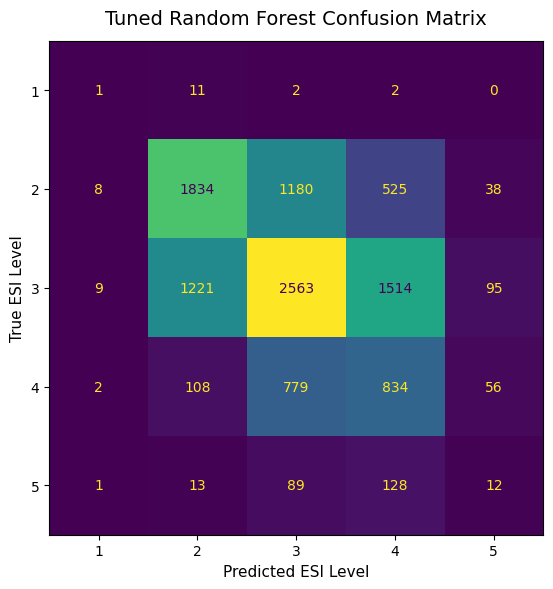

In [138]:
# Calculate the tuned Random Forest confusion matrix
tuned_random_forest_cm = confusion_matrix(
    y_test,
    tuned_random_forest_predictions,
    labels=ESI_LABELS
)

# Create the figure
fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_random_forest_cm,
    display_labels=ESI_LABELS
)

display.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Tuned Random Forest Confusion Matrix",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Predicted ESI Level",
    fontsize=11
)

ax.set_ylabel(
    "True ESI Level",
    fontsize=11
)

plt.tight_layout()
plt.show()

## Tuned Random Forest Feature Importance

Feature importance is recalculated using the tuned Random Forest because this is the complex model included in the final interim benchmark.

The values show which predictors contributed most frequently to reducing classification uncertainty across the forest. They provide a global model explanation but do not explain one individual patient prediction.

The importance values must not be interpreted as proof that a predictor caused the recorded ESI level.

In [139]:
# Link the tuned model's importance values
# to the ten predictor names
tuned_feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": (
        tuned_random_forest_model.feature_importances_
    )
})

# Sort the predictors from most important to least important
tuned_feature_importance = (
    tuned_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Tuned Random Forest feature importance:")
tuned_feature_importance

Tuned Random Forest feature importance:


,Feature,Importance
0,triage_vital_sbp,0.226905
1,age,0.192908
2,triage_glucose,0.173667
3,triage_vital_hr,0.167465
4,triage_vital_o2,0.072409
5,triage_vital_rr,0.069486
6,triage_vital_o2_device,0.059660
7,cc_chestpain,0.021870
8,cc_shortnessofbreath,0.009007
9,cc_alteredmentalstatus,0.006625


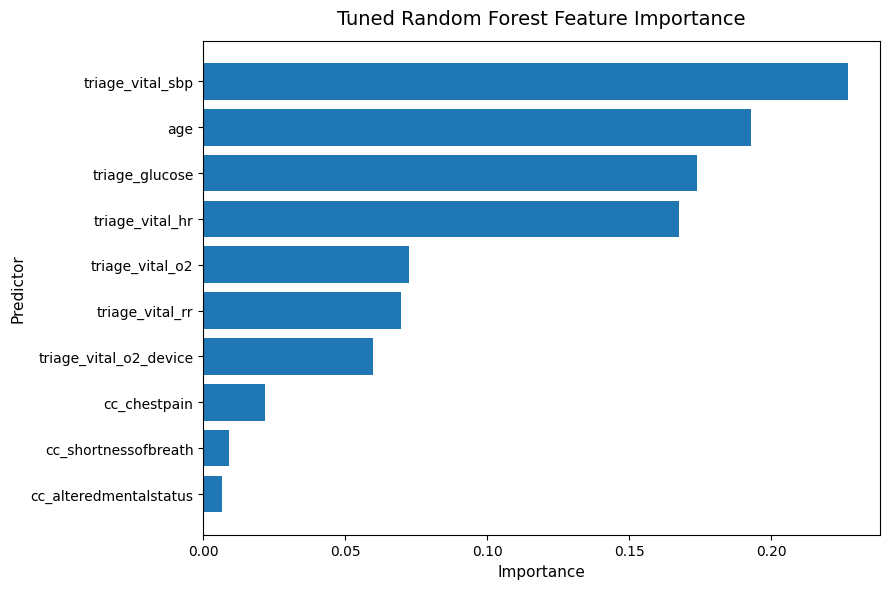

In [140]:
# Sort the values for a horizontal bar chart
tuned_importance_plot_data = (
    tuned_feature_importance
    .sort_values(
        by="Importance",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    tuned_importance_plot_data["Feature"],
    tuned_importance_plot_data["Importance"]
)

ax.set_title(
    "Tuned Random Forest Feature Importance",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Importance",
    fontsize=11
)

ax.set_ylabel(
    "Predictor",
    fontsize=11
)

plt.tight_layout()
plt.show()

## Interim Findings and Provisional Recommendation

The Week 7 interim objective was achieved by rebuilding the original Logistic Regression and Decision Tree baselines and comparing them with an initial and tuned Random Forest using the same ten predictors, training patients, test patients and random seed.

The tuned Random Forest achieved the strongest macro F1-score at 0.302, compared with 0.222 for Logistic Regression and 0.215 for the Decision Tree. It also produced the strongest macro recall and slightly improved weighted F1. These results show that the Random Forest provided a more balanced performance across the five ESI categories.

However, the improvement did not translate into reliable recognition of the most critical patients. The tuned Random Forest correctly identified only one of the 16 ESI Level 1 patients, producing recall of 0.063. Fifteen critically urgent patients were still missed, including two assigned to ESI Level 4.

The tuned model also produced ESI Level 1 precision of only 0.048, indicating that most Level 1 alerts were false alarms. In practice, a high number of false critical alerts could increase staff workload and contribute to alert fatigue.

Accuracy decreased from 0.545 for Logistic Regression to 0.476 for the tuned Random Forest. Training time increased from approximately 0.99 seconds to 27.52 seconds, while interpretability decreased from high to moderate. Although Random Forest inference was slower, the absolute prediction time remained very small at approximately 0.054 milliseconds per patient.

Cross-validation also revealed substantial overfitting. The tuned model achieved training macro F1 of 0.761 but validation macro F1 of only 0.288.

Based on the interim evidence, the tuned Random Forest should not yet replace the original Logistic Regression baseline. It provides better balanced performance across the five ESI levels, but the small improvement in ESI Level 1 detection does not currently justify the lower accuracy, increased false alarms, greater computational cost and reduced interpretability.

The Random Forest should remain an experimental candidate while the causes of its errors are investigated. Further work should focus on improved triage-time predictors, stronger control of overfitting and the limited number of ESI Level 1 examples rather than assuming that greater model complexity alone will solve the problem.

## Save the Interim Outputs

The benchmark table, ESI Level 1 error analysis, cross-validation results and feature-importance values are saved as CSV files. These outputs can be committed to the Week 7 documentation folder and used to create the draft benchmark table.

In [141]:
# Create a Week 7 output folder in Google Drive
WEEK7_OUTPUT_FOLDER = (
    "/content/drive/MyDrive/CARISURG/Week7"
)

os.makedirs(
    WEEK7_OUTPUT_FOLDER,
    exist_ok=True
)

# Define the output file locations
benchmark_path = os.path.join(
    WEEK7_OUTPUT_FOLDER,
    "week7_interim_benchmark.csv"
)

esi1_errors_path = os.path.join(
    WEEK7_OUTPUT_FOLDER,
    "week7_esi1_error_analysis.csv"
)

tuning_results_path = os.path.join(
    WEEK7_OUTPUT_FOLDER,
    "week7_random_forest_tuning_results.csv"
)

feature_importance_path = os.path.join(
    WEEK7_OUTPUT_FOLDER,
    "week7_tuned_random_forest_feature_importance.csv"
)

# Save the tables
updated_benchmark_table.to_csv(
    benchmark_path,
    index=False
)

updated_esi1_error_display.to_csv(
    esi1_errors_path,
    index=False
)

random_forest_search_summary.to_csv(
    tuning_results_path,
    index=False
)

tuned_feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print("Week 7 interim files saved successfully.")

print("\nSaved files:")
print("-", benchmark_path)
print("-", esi1_errors_path)
print("-", tuning_results_path)
print("-", feature_importance_path)

Week 7 interim files saved successfully.

Saved files:
- /content/drive/MyDrive/CARISURG/Week7/week7_interim_benchmark.csv
- /content/drive/MyDrive/CARISURG/Week7/week7_esi1_error_analysis.csv
- /content/drive/MyDrive/CARISURG/Week7/week7_random_forest_tuning_results.csv
- /content/drive/MyDrive/CARISURG/Week7/week7_tuned_random_forest_feature_importance.csv
